In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Used for data manipulation and analysis (e.g., DataFrames)
import numpy as np # Used for numerical operations, especially with arrays

In [ ]:
# Load the dataset from the specified CSV file into a pandas DataFrame
df = pd.read_csv('/content/placement (1).csv')

In [ ]:
# Display the first row of the DataFrame to get a quick overview of the data structure and content
df.head(1)

,cgpa,package
0,6.89,3.26


Text(0.5, 1.0, 'scatter plot')

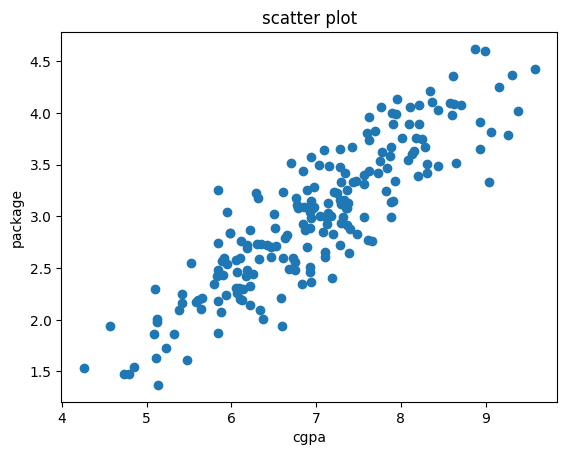

In [ ]:
# Create a scatter plot to visualize the relationship between 'cgpa' and 'package'
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('cgpa') # Label for the x-axis
plt.ylabel('package') # Label for the y-axis
plt.title('scatter plot') # Title of the scatter plot
plt.show() # Display the plot

In [ ]:
# Separate the features (X) and the target variable (y)
# X will contain the 'cgpa' column (all rows, first column)
X = df.iloc[:,0:1]
# y will contain the 'package' column (all rows, second column)
y = df.iloc[:, 1]

In [ ]:
# Display the target variable 'y' (package) to inspect its values
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [ ]:
# Import the train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
# X_train, y_train will be used for training the model
# X_test, y_test will be used for evaluating the model
# test_size=0.2 means 20% of the data will be used for testing, 80% for training
# random_state=2 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [ ]:
# Import the LinearRegression model from scikit-learn
from sklearn.linear_model import LinearRegression
# Create an instance of the LinearRegression model
lr = LinearRegression()

In [ ]:
# Train the Linear Regression model using the training data
lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'package')

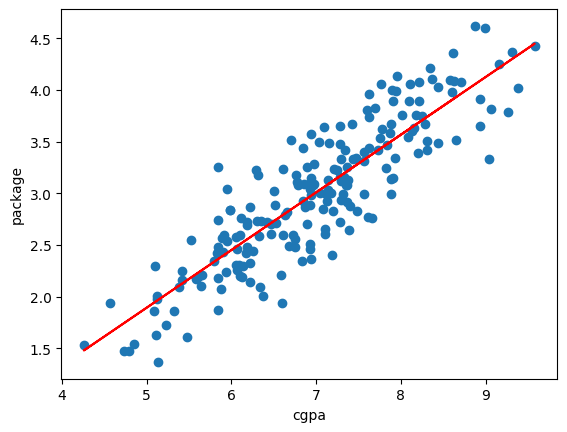

In [ ]:
# Re-create the scatter plot of 'cgpa' vs 'package'
plt.scatter(df['cgpa'], df['package'])
# Plot the regression line using the trained model's predictions on the training data
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.xlabel('cgpa') # Label for the x-axis
plt.ylabel('package') # Label for the y-axis
plt.show() # Display the plot

In [ ]:
# Import evaluation metrics from scikit-learn
# mean_absolute_error (MAE): measures the average magnitude of the errors
# mean_squared_error (MSE): measures the average of the squares of the errors
# r2_score: represents the proportion of variance in the dependent variable that is predictable from the independent variable(s)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Make predictions on the test set using the trained Linear Regression model
y_pred = lr.predict(X_test)

In [ ]:
# Calculate and print the Mean Absolute Error (MAE) between actual (y_test) and predicted (y_pred) values
print("MAE: ", mean_absolute_error(y_test, y_pred))

MAE:  0.2884710931878175


In [ ]:
# Calculate and print the Mean Squared Error (MSE) between actual (y_test) and predicted (y_pred) values
print("MSE: ", mean_squared_error(y_test, y_pred))

MSE:  0.12129235313495527


In [ ]:
# Calculate and print the Root Mean Squared Error (RMSE) by taking the square root of MSE
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE:  0.34827051717731616


In [ ]:
# Calculate and print the R2 Score (coefficient of determination)
print("R2 Score: ", r2_score(y_test, y_pred))
# Store the R2 Score in a variable for further calculations (e.g., Adjusted R2 Score)
r2 = r2_score(y_test, y_pred)

R2 Score:  0.780730147510384


In [ ]:
# Calculate the Adjusted R2 Score
# This metric adjusts the R2 score based on the number of predictors in the model.
# It penalizes adding independent variables that do not improve the model's explanatory power.
# Formula: 1 - ((1 - R^2) * (n - 1) / (n - p - 1)), where n is the number of samples, and p is the number of predictors.
# Here, n = len(y_test), p = 1 (since 'cgpa' is the only predictor)
1 - ((1 - r2) * (len(y_test) - 1) / (len(y_test) - 1 - 1))

0.7749598882343415